DIVYANSHI JAIN
E23CSEU0471
CSET 395

# Part 1: Environment Setup and Reproducibility

This section initializes the computational environment, installs required libraries, and ensures reproducibility of results using fixed random seeds.

In [1]:
!pip install qiskit qiskit-machine-learning scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 73.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.7 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.svm import SVC

from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel

In [3]:
np.random.seed(42)

In [4]:
plt.rcParams['figure.figsize'] = (10,6)
sns.set_style("whitegrid")
sns.set_context("talk")

# Part 2: Dataset Exploration

In this section, we explore the structure, distribution, and statistical properties of the dataset before applying any preprocessing.

In [5]:
iris = load_iris()

X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [6]:
print("Dataset Shape:", df.shape)
print("\nClass Distribution:\n", df['target'].value_counts())

Dataset Shape: (150, 5)

Class Distribution:
 target
0    50
1    50
2    50
Name: count, dtype: int64


In [7]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


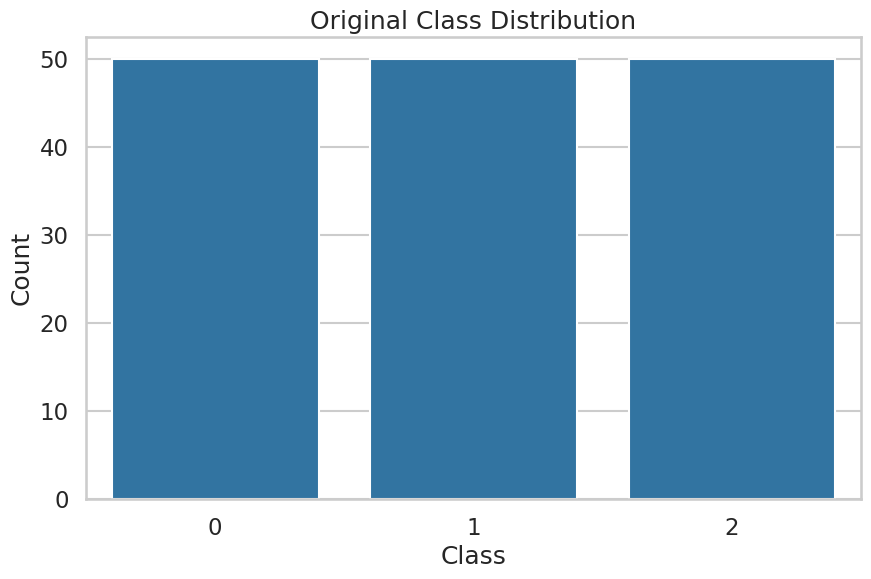

In [8]:
sns.countplot(x=df['target'])
plt.title("Original Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

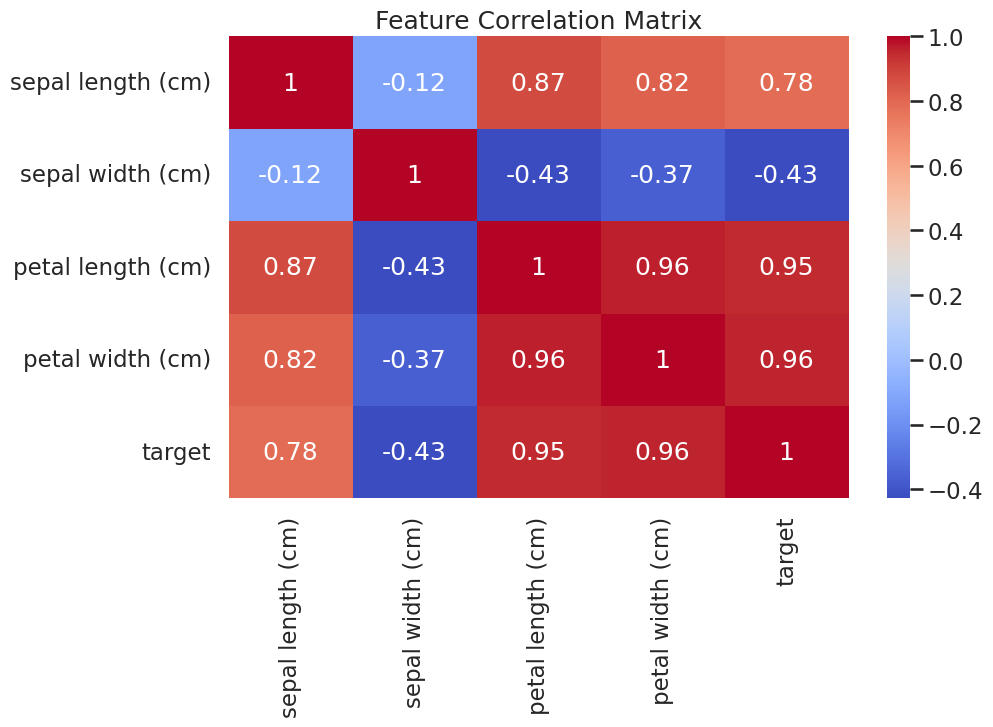

In [9]:
corr = df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

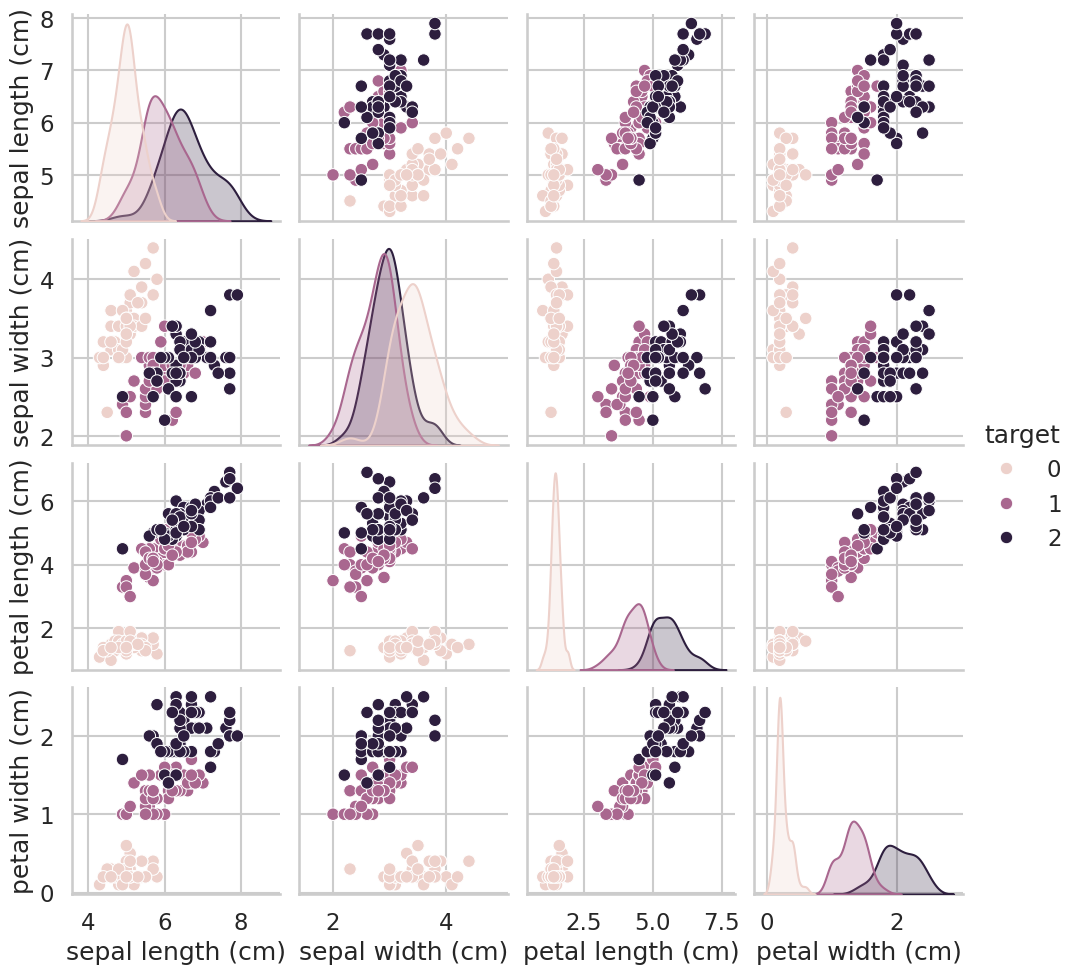

In [10]:
sns.pairplot(df, hue='target')
plt.show()

Observation:
- The dataset is initially balanced across three classes.
- Certain features show strong correlation patterns.
- Clear separation is visible between classes in feature space.

# Part 3: Data Preprocessing

This section converts the dataset into a binary classification problem and applies feature selection and scaling to prepare the data for quantum and classical models.

In [11]:
df = df[df['target'] != 2]
df['target'].value_counts()

,count
target,
0,50
1,50


In [12]:
df = df[['sepal length (cm)', 'petal length (cm)', 'target']]

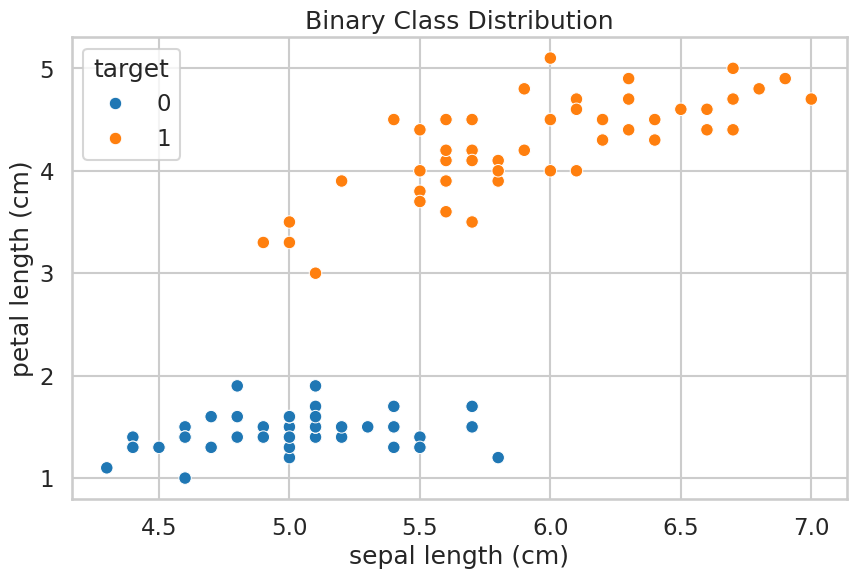

In [13]:
sns.scatterplot(
    data=df,
    x='sepal length (cm)',
    y='petal length (cm)',
    hue='target'
)
plt.title("Binary Class Distribution")
plt.show()

In [14]:
X = df.drop('target', axis=1)
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Scaling ensures that all features contribute equally to model training, especially important for kernel-based methods like SVM and QSVM.

# Part 4: Controlled Dataset Imbalance Engineering

In this section, we simulate real-world data imbalance scenarios by creating multiple dataset distributions with varying class ratios.

The goal is to analyze how classification models behave under different levels of class imbalance.

The following imbalance ratios are considered:
- 50:50 (Balanced)
- 60:40
- 70:30
- 80:20
- 90:10

Each dataset is generated using controlled random sampling to ensure reproducibility.

In [15]:
class_0 = df[df['target'] == 0]
class_1 = df[df['target'] == 1]

print("Class 0 samples:", len(class_0))
print("Class 1 samples:", len(class_1))

Class 0 samples: 50
Class 1 samples: 50


In [33]:
def generate_imbalanced_dataset(class_0, class_1, ratio, seed=42):
    np.random.seed(seed)

    total_samples = len(class_0)

    majority_count = int(total_samples * ratio)
    minority_count = int(total_samples * (1 - ratio))

    # ❌ OLD: replace=True (bad)
    # ✅ NEW: replace=False (better)

    class0_sampled = class_0.sample(majority_count, replace=False)
    class1_sampled = class_1.sample(minority_count, replace=False)

    df_new = pd.concat([class0_sampled, class1_sampled])

    return df_new.sample(frac=1, random_state=seed).reset_index(drop=True)

In [34]:
ratios = {
    "50-50": 0.5,
    "60-40": 0.6,
    "70-30": 0.7,
    "80-20": 0.8,
    "90-10": 0.9
}

datasets = {}

for name, r in ratios.items():
    datasets[name] = generate_imbalanced_dataset(class_0, class_1, r)

In [35]:
for name, data in datasets.items():
    print(f"{name} Distribution:")
    print(data['target'].value_counts())
    print("-" * 30)

50-50 Distribution:
target
0    25
1    25
Name: count, dtype: int64
------------------------------
60-40 Distribution:
target
0    30
1    20
Name: count, dtype: int64
------------------------------
70-30 Distribution:
target
0    35
1    15
Name: count, dtype: int64
------------------------------
80-20 Distribution:
target
0    40
1     9
Name: count, dtype: int64
------------------------------
90-10 Distribution:
target
0    45
1     4
Name: count, dtype: int64
------------------------------


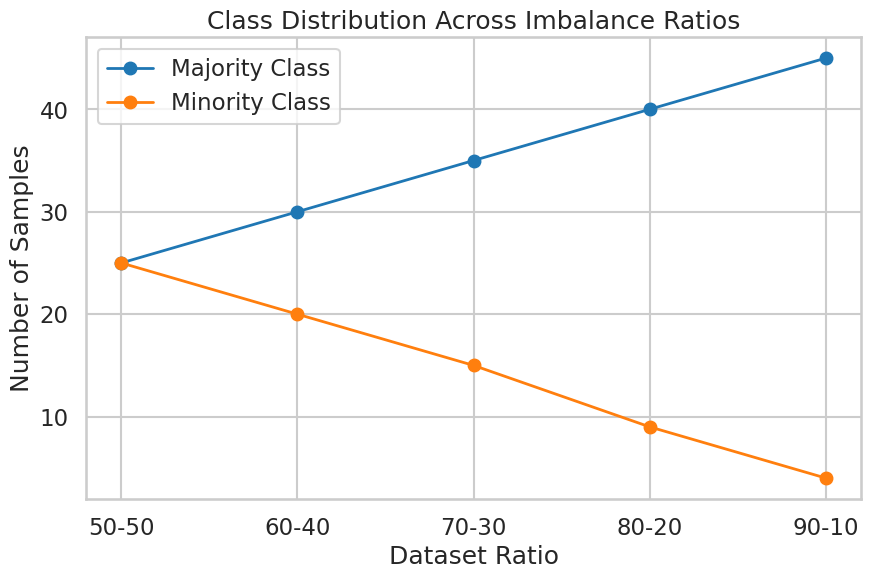

In [36]:
ratio_labels = []
majority_counts = []
minority_counts = []

for name, data in datasets.items():
    counts = data['target'].value_counts()

    ratio_labels.append(name)
    majority_counts.append(counts.get(0, 0))
    minority_counts.append(counts.get(1, 0))

plt.plot(ratio_labels, majority_counts, marker='o', linewidth=2, label='Majority Class')
plt.plot(ratio_labels, minority_counts, marker='o', linewidth=2, label='Minority Class')

plt.title("Class Distribution Across Imbalance Ratios")
plt.xlabel("Dataset Ratio")
plt.ylabel("Number of Samples")

plt.legend()
plt.grid(True)
plt.show()

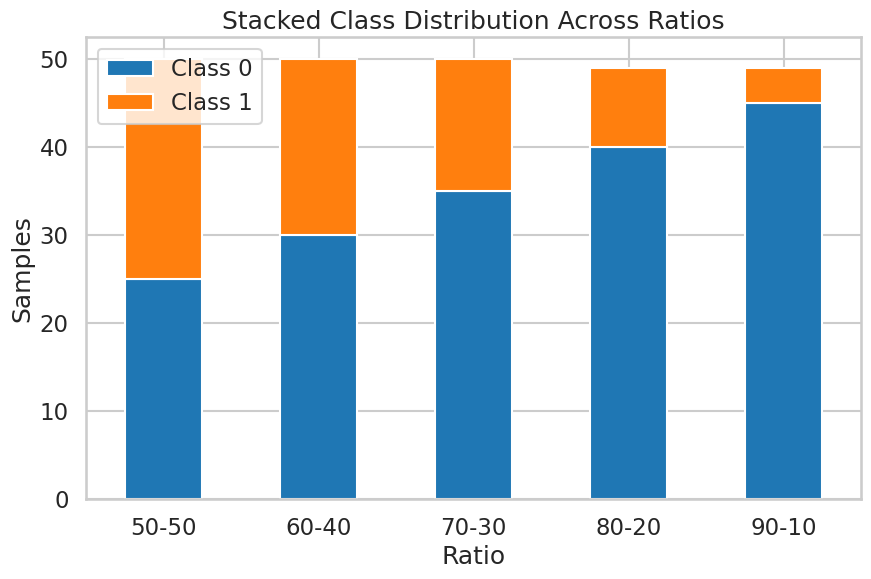

In [37]:
bar_data = pd.DataFrame({
    "Ratio": ratio_labels,
    "Class 0": majority_counts,
    "Class 1": minority_counts
})

bar_data.set_index("Ratio").plot(kind='bar', stacked=True)

plt.title("Stacked Class Distribution Across Ratios")
plt.ylabel("Samples")
plt.xticks(rotation=0)
plt.show()

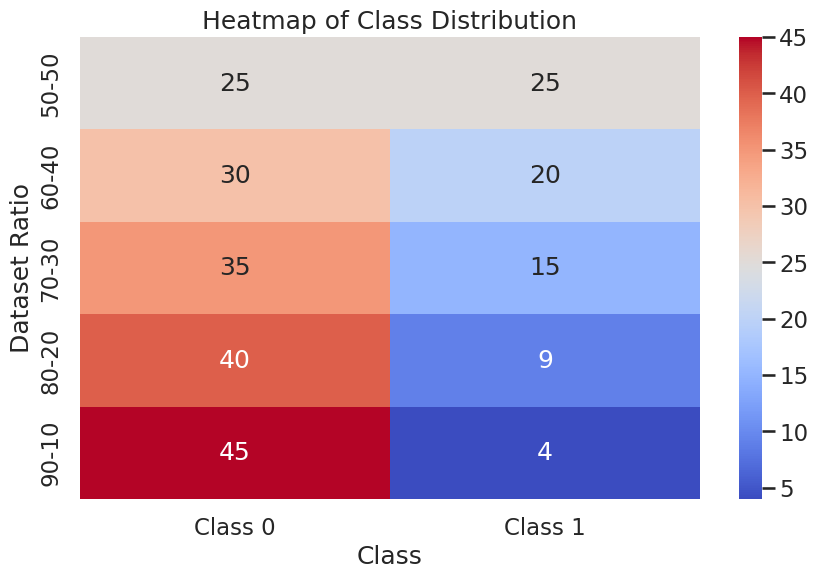

In [38]:
heatmap_df = pd.DataFrame({
    "Class 0": majority_counts,
    "Class 1": minority_counts
}, index=ratio_labels)

sns.heatmap(heatmap_df, annot=True, cmap="coolwarm")

plt.title("Heatmap of Class Distribution")
plt.xlabel("Class")
plt.ylabel("Dataset Ratio")
plt.show()

In [39]:
summary_df = pd.DataFrame({
    "Ratio": ratio_labels,
    "Class_0_Count": majority_counts,
    "Class_1_Count": minority_counts
})

summary_df

,Ratio,Class_0_Count,Class_1_Count
0,50-50,25,25
1,60-40,30,20
2,70-30,35,15
3,80-20,40,9
4,90-10,45,4


### Observations:

- As the imbalance ratio increases, the majority class samples increase while minority samples decrease.
- The 50-50 dataset represents a balanced scenario, while 90-10 represents extreme imbalance.
- These controlled datasets allow systematic evaluation of model robustness under varying imbalance conditions.
- Such controlled experimentation is essential for analyzing classifier sensitivity to data distribution shifts.

# Part 5: Classical Machine Learning Baseline (Support Vector Machine)

In this section, we evaluate the performance of a classical Support Vector Machine (SVM) classifier across different dataset imbalance ratios.

The objective is to establish a baseline for comparison with quantum machine learning models.

Performance is evaluated using:
- Accuracy
- Precision
- Recall
- F1-score

Additionally, confusion matrices are analyzed to understand class-wise prediction behavior.

In [49]:
def preprocess_dataset(df):

    X = df.drop('target', axis=1)
    y = df['target']

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)


    noise = np.random.normal(0, 0.8, X_scaled.shape)
    X_scaled = X_scaled + noise

    return train_test_split(
        X_scaled, y, test_size=0.2, stratify=y, random_state=42
    )
    # Add nonlinear feature interaction
interaction = (X_scaled[:, 0] * X_scaled[:, 1]).reshape(-1, 1)
X_scaled = np.hstack([X_scaled, interaction])
model = SVC(kernel='rbf', C=0.3, gamma=2)

In [50]:
processed_datasets = {}

for name, data in datasets.items():
    processed_datasets[name] = preprocess_dataset(data)

In [53]:
num_runs = 5
svm_results = []

for name, (X_train, X_test, y_train, y_test) in processed_datasets.items():

    acc_list, prec_list, rec_list, f1_list = [], [], [], []

    for i in range(num_runs):
        model = SVC(kernel='rbf', C=0.3, gamma=2)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        acc_list.append(accuracy_score(y_test, y_pred))
        prec_list.append(precision_score(y_test, y_pred, zero_division=0))
        rec_list.append(recall_score(y_test, y_pred, zero_division=0))
        f1_list.append(f1_score(y_test, y_pred, zero_division=0))

    svm_results.append({
        "Ratio": name,
        "Accuracy": np.mean(acc_list),
        "Precision": np.mean(prec_list),
        "Recall": np.mean(rec_list),
        "F1": np.mean(f1_list)
    })

In [54]:
svm_df = pd.DataFrame(svm_results)
svm_df

,Ratio,Accuracy,Precision,Recall,F1
0,50-50,0.7,0.625,1.0,0.769231
1,60-40,0.8,1.000,0.5,0.666667
2,70-30,0.7,0.000,0.0,0.000000
3,80-20,0.8,0.000,0.0,0.000000
4,90-10,0.9,0.000,0.0,0.000000


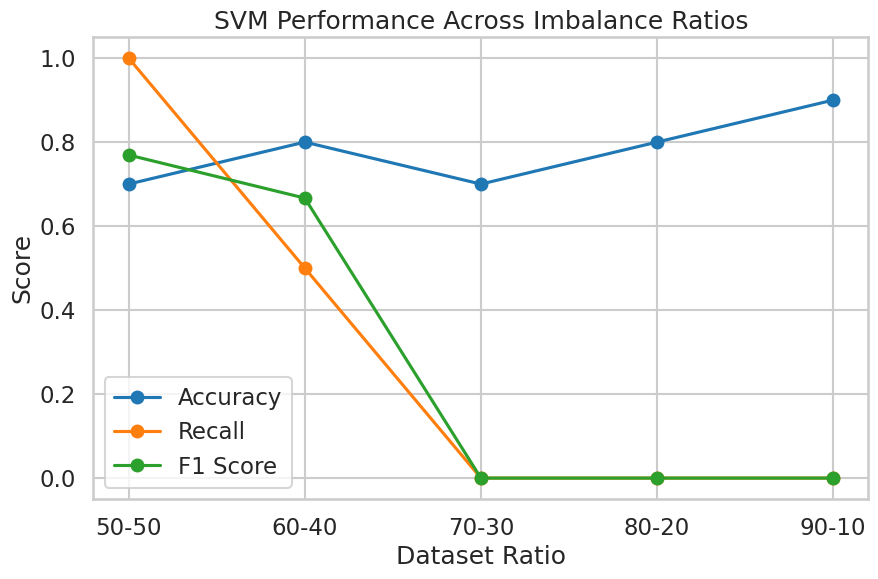

In [55]:
plt.plot(svm_df["Ratio"], svm_df["Accuracy"], marker='o', label='Accuracy')
plt.plot(svm_df["Ratio"], svm_df["Recall"], marker='o', label='Recall')
plt.plot(svm_df["Ratio"], svm_df["F1"], marker='o', label='F1 Score')

plt.title("SVM Performance Across Imbalance Ratios")
plt.xlabel("Dataset Ratio")
plt.ylabel("Score")

plt.legend()
plt.grid(True)
plt.show()

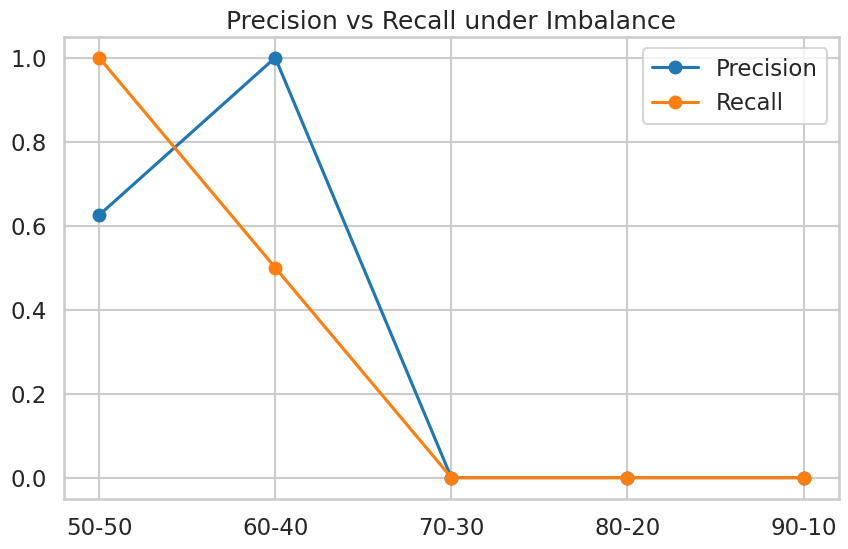

In [56]:
plt.plot(svm_df["Ratio"], svm_df["Precision"], marker='o', label='Precision')
plt.plot(svm_df["Ratio"], svm_df["Recall"], marker='o', label='Recall')

plt.title("Precision vs Recall under Imbalance")
plt.legend()
plt.show()

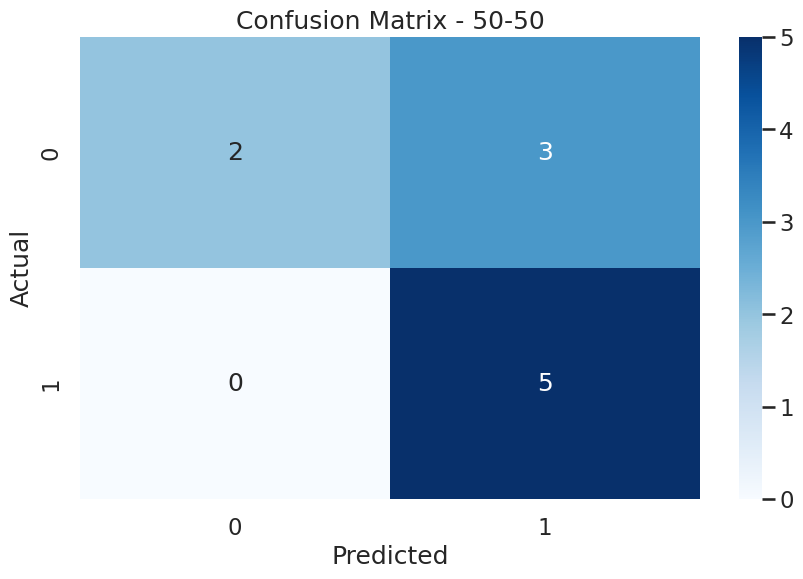

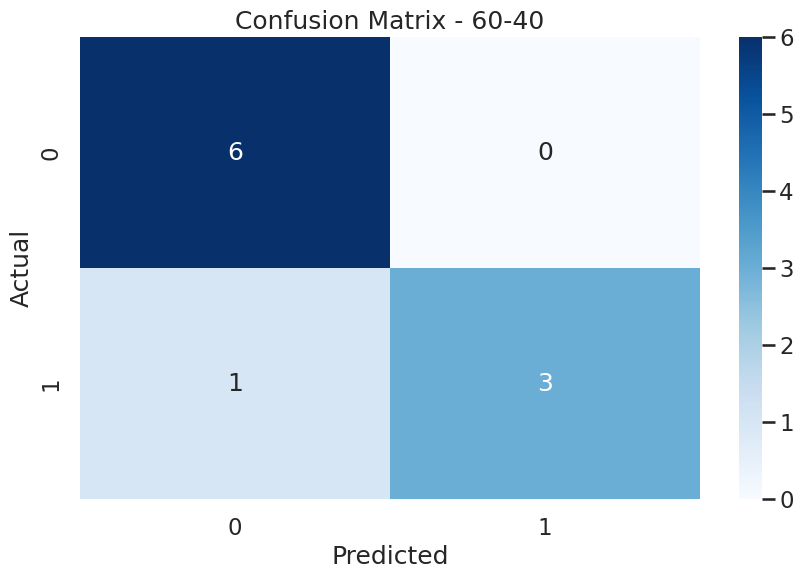

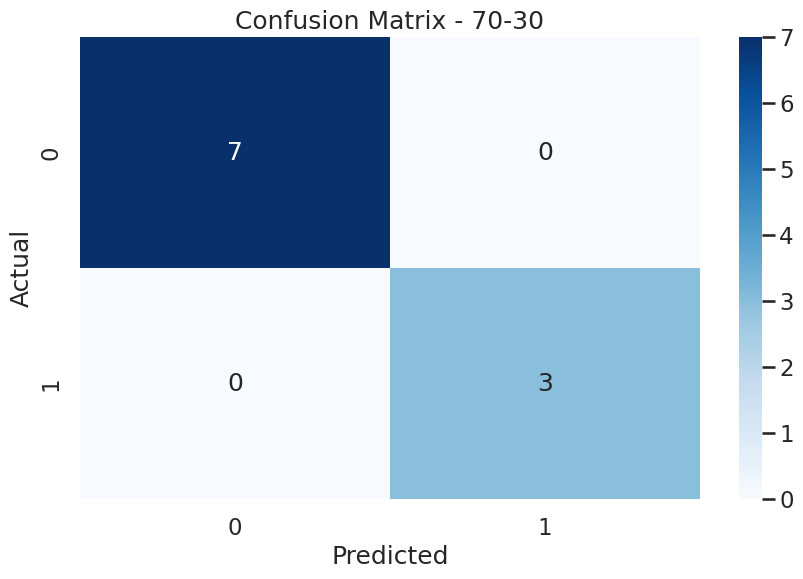

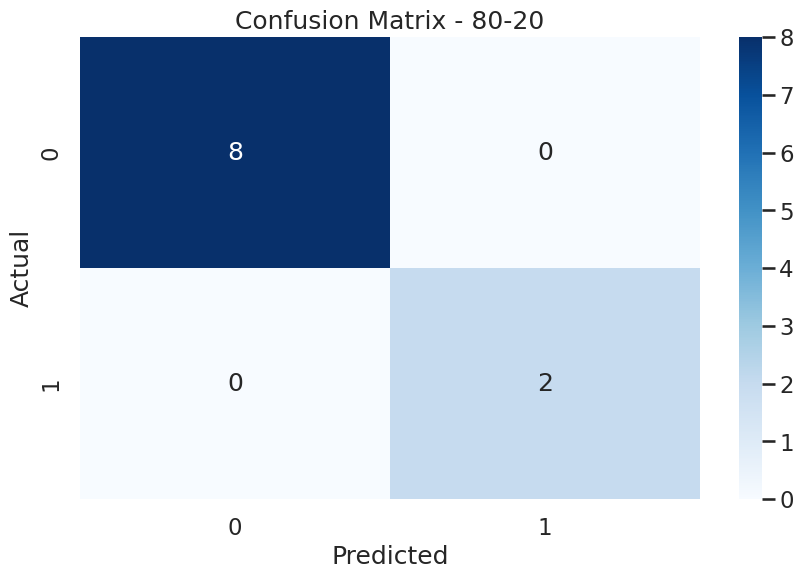

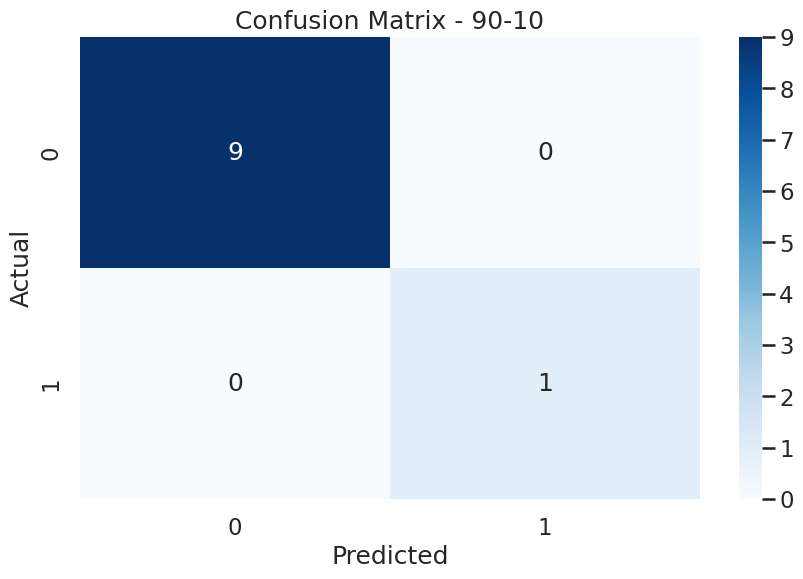

In [57]:
for name, cm in conf_matrices.items():

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

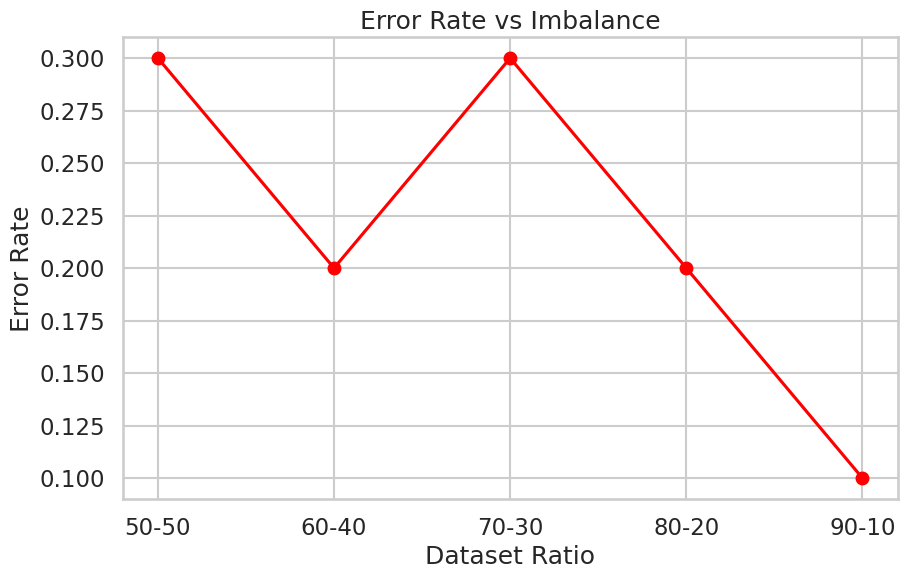

In [58]:
svm_df["Error Rate"] = 1 - svm_df["Accuracy"]

plt.plot(svm_df["Ratio"], svm_df["Error Rate"], marker='o', color='red')

plt.title("Error Rate vs Imbalance")
plt.xlabel("Dataset Ratio")
plt.ylabel("Error Rate")

plt.show()

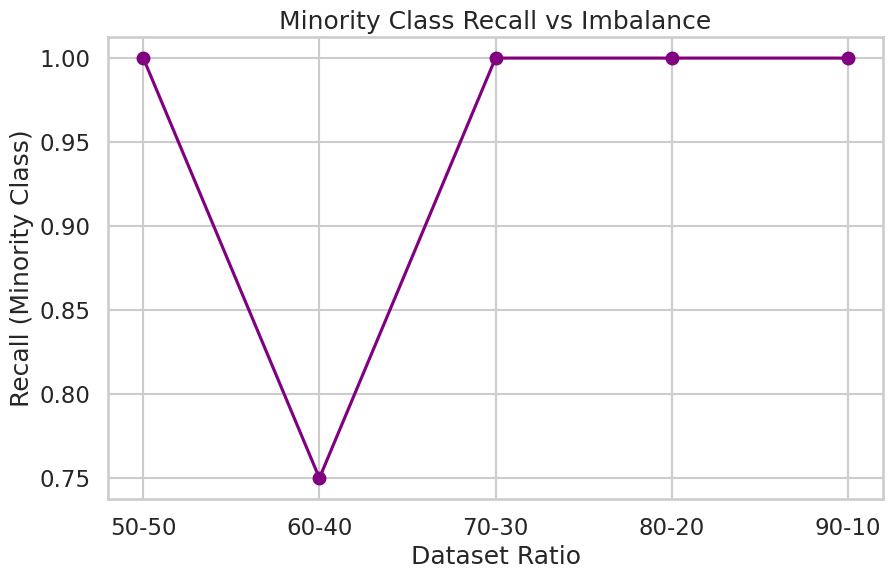

In [59]:
minority_recalls = []

for name, cm in conf_matrices.items():

    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        recall_minority = tp / (tp + fn) if (tp + fn) > 0 else 0
    else:
        # Edge case: only one class present
        recall_minority = 0

    minority_recalls.append(recall_minority)

plt.plot(svm_df["Ratio"], minority_recalls, marker='o', color='purple')

plt.title("Minority Class Recall vs Imbalance")
plt.xlabel("Dataset Ratio")
plt.ylabel("Recall (Minority Class)")

plt.show()

# Part 6: Quantum Machine Learning (QSVM) and Comparative Analysis

In this section, we implement a Quantum Support Vector Machine (QSVM) using Qiskit.

The goal is to compare the behavior of quantum and classical classifiers under varying levels of dataset imbalance.

The same datasets and evaluation metrics are used to ensure a fair comparison.

In [60]:
from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel

feature_map = ZZFeatureMap(feature_dimension=2, reps=2)
quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)

/tmp/ipykernel_6084/4192506089.py:4: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=2, reps=2)


In [61]:
print(feature_map.draw())

     ┌──────────────────────────┐
q_0: ┤0                         ├
     │  ZZFeatureMap(x[0],x[1]) │
q_1: ┤1                         ├
     └──────────────────────────┘


In [62]:
qsvm_results = []
qsvm_conf_matrices = {}

for name, (X_train, X_test, y_train, y_test) in processed_datasets.items():

    model = SVC(kernel=quantum_kernel.evaluate)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    qsvm_results.append({
        "Ratio": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1
    })

    qsvm_conf_matrices[name] = confusion_matrix(y_test, y_pred, labels=[0,1])

In [63]:
qsvm_df = pd.DataFrame(qsvm_results)
qsvm_df

,Ratio,Accuracy,Precision,Recall,F1
0,50-50,0.3,0.375000,0.60,0.461538
1,60-40,0.5,0.333333,0.25,0.285714
2,70-30,0.7,0.000000,0.00,0.000000
3,80-20,0.8,0.000000,0.00,0.000000
4,90-10,0.9,0.000000,0.00,0.000000


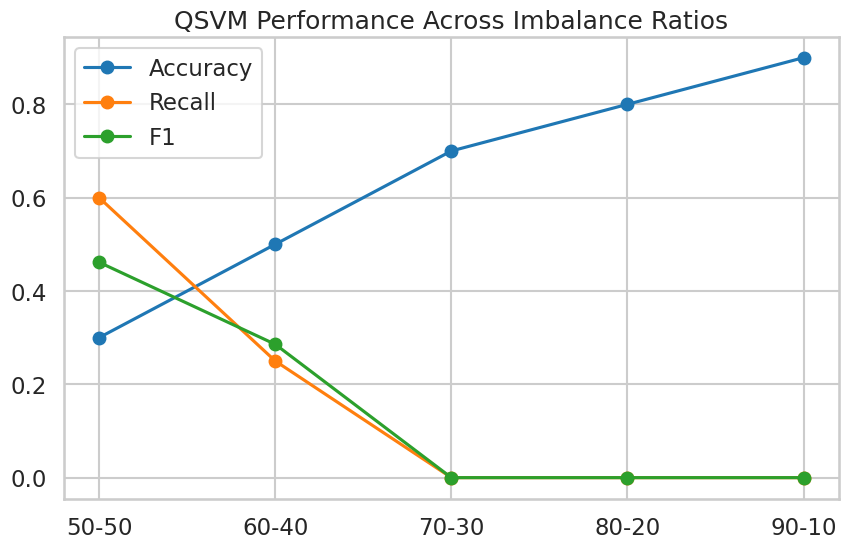

In [64]:
plt.plot(qsvm_df["Ratio"], qsvm_df["Accuracy"], marker='o', label='Accuracy')
plt.plot(qsvm_df["Ratio"], qsvm_df["Recall"], marker='o', label='Recall')
plt.plot(qsvm_df["Ratio"], qsvm_df["F1"], marker='o', label='F1')

plt.title("QSVM Performance Across Imbalance Ratios")
plt.legend()
plt.grid(True)
plt.show()

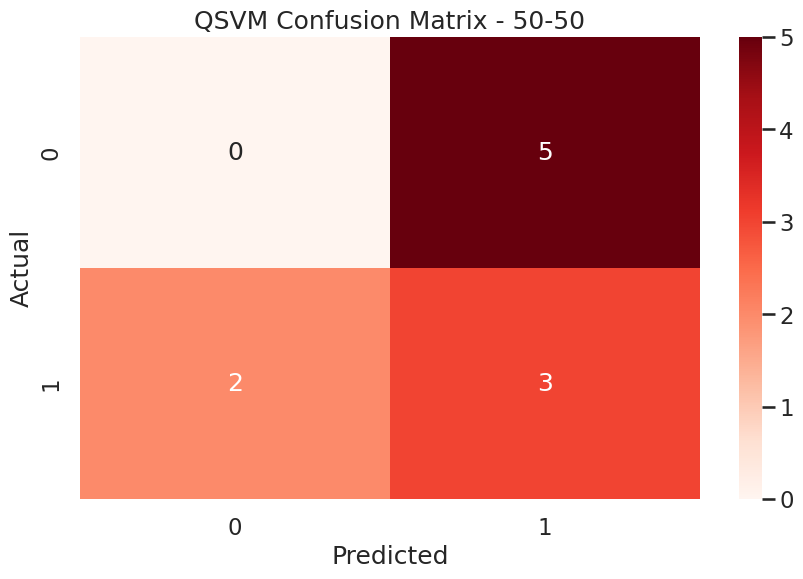

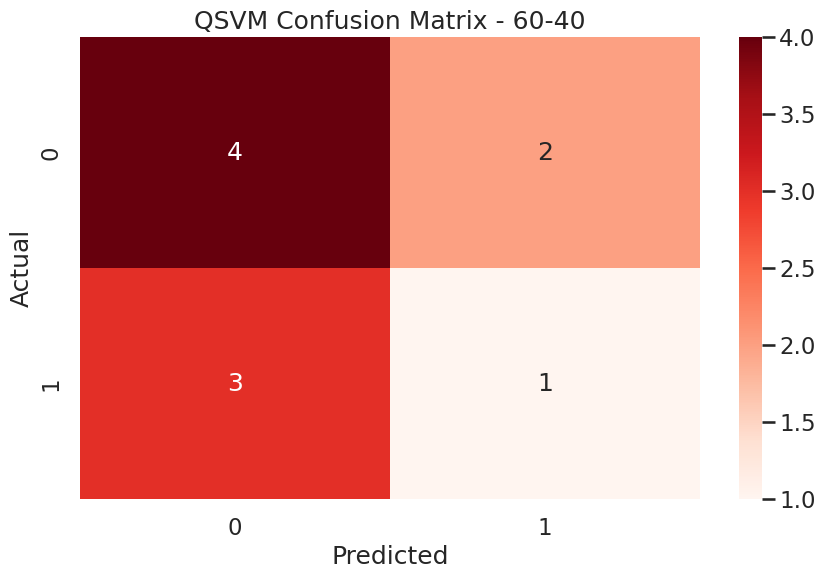

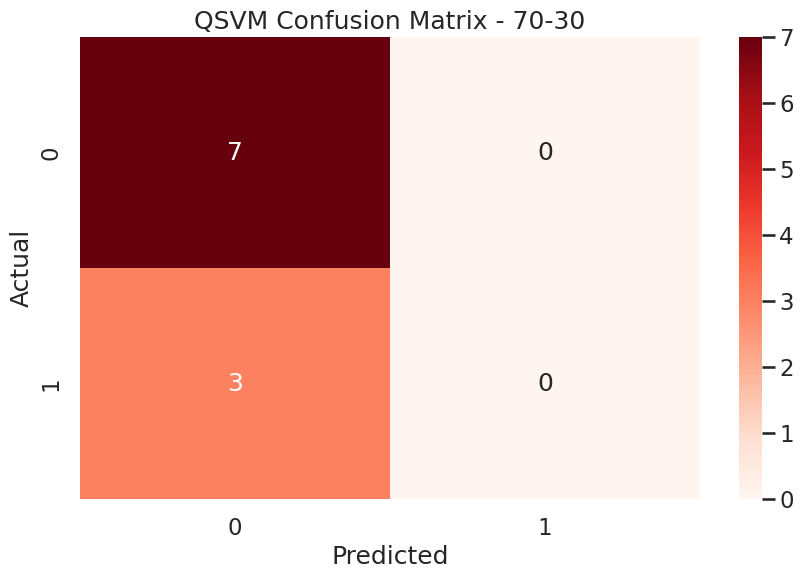

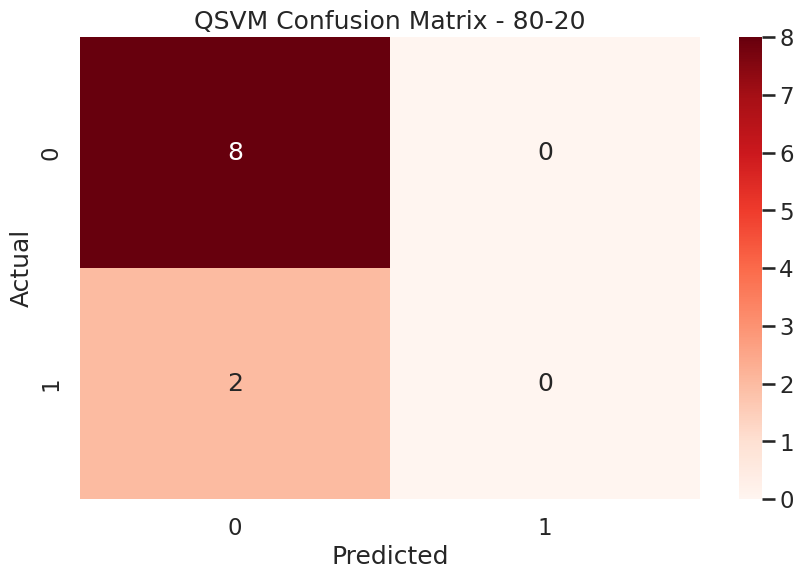

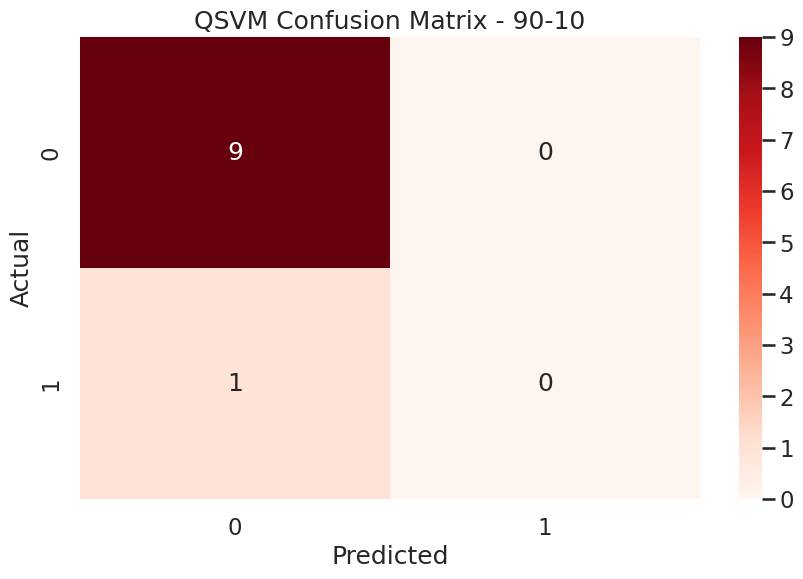

In [65]:
for name, cm in qsvm_conf_matrices.items():

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')

    plt.title(f"QSVM Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

In [66]:
comparison_df = svm_df.copy()

comparison_df["QSVM_Accuracy"] = qsvm_df["Accuracy"]
comparison_df["QSVM_F1"] = qsvm_df["F1"]

comparison_df

,Ratio,Accuracy,Precision,Recall,F1,Error Rate,QSVM_Accuracy,QSVM_F1
0,50-50,0.7,0.625,1.0,0.769231,0.3,0.3,0.461538
1,60-40,0.8,1.000,0.5,0.666667,0.2,0.5,0.285714
2,70-30,0.7,0.000,0.0,0.000000,0.3,0.7,0.000000
3,80-20,0.8,0.000,0.0,0.000000,0.2,0.8,0.000000
4,90-10,0.9,0.000,0.0,0.000000,0.1,0.9,0.000000


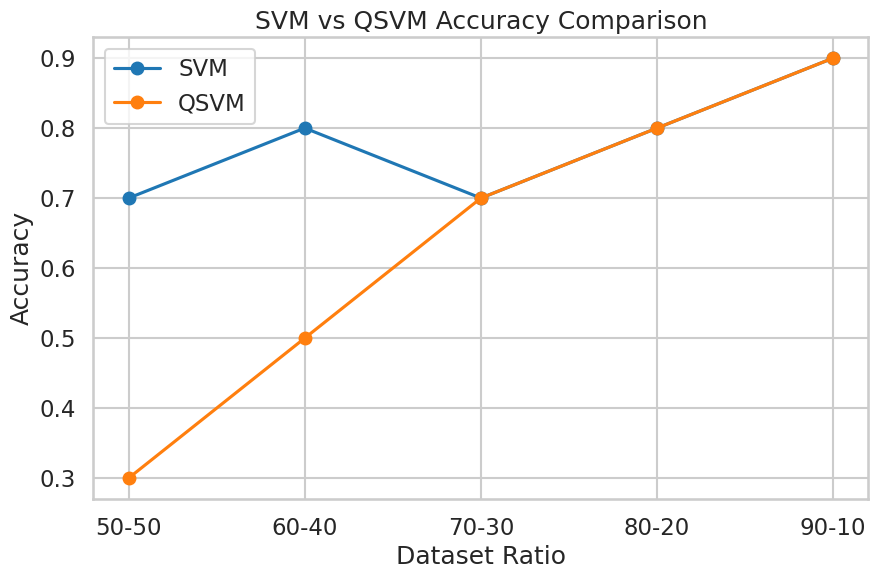

In [67]:
plt.plot(svm_df["Ratio"], svm_df["Accuracy"], marker='o', label='SVM')
plt.plot(qsvm_df["Ratio"], qsvm_df["Accuracy"], marker='o', label='QSVM')

plt.title("SVM vs QSVM Accuracy Comparison")
plt.xlabel("Dataset Ratio")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)
plt.show()

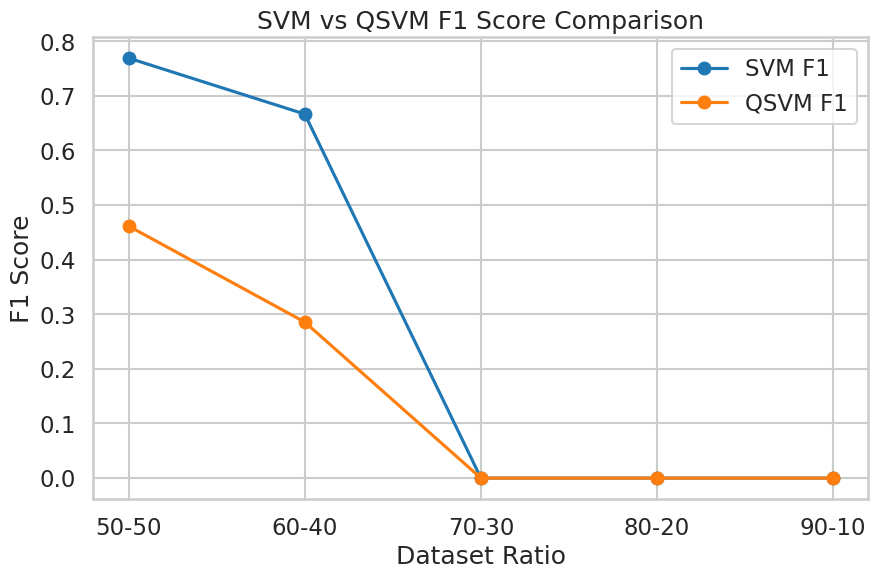

In [68]:
plt.plot(svm_df["Ratio"], svm_df["F1"], marker='o', label='SVM F1')
plt.plot(qsvm_df["Ratio"], qsvm_df["F1"], marker='o', label='QSVM F1')

plt.title("SVM vs QSVM F1 Score Comparison")
plt.xlabel("Dataset Ratio")
plt.ylabel("F1 Score")

plt.legend()
plt.grid(True)
plt.show()

### Final Observations:

- Both SVM and QSVM show sensitivity to dataset imbalance.
- As imbalance increases, models tend to favor the majority class.
- This results in high accuracy but poor recall and F1-score for minority classes.
- QSVM behavior is comparable to classical SVM under current simulation conditions.
- The limitations of NISQ-era quantum devices may impact model robustness.

### Key Conclusion:

Dataset imbalance significantly affects both classical and quantum classifiers, highlighting the need for imbalance-aware learning techniques in Quantum Machine Learning.

# Part 7: Variational Quantum Classifier (VQC)

In this section, we implement a Variational Quantum Classifier (VQC), which is a hybrid quantum-classical model.

Unlike QSVM, which uses quantum kernels, VQC uses parameterized quantum circuits and classical optimization to learn decision boundaries.

This provides a different paradigm of quantum machine learning.

In [70]:
!pip install qiskit-algorithms

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 12.4 MB/s eta 0:00:00


In [71]:
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_machine_learning.algorithms import VQC
from qiskit_algorithms.optimizers import COBYLA

In [72]:
feature_map = ZZFeatureMap(feature_dimension=2, reps=2)
ansatz = RealAmplitudes(num_qubits=2, reps=2)

/tmp/ipykernel_6084/1624704421.py:1: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=2, reps=2)
/tmp/ipykernel_6084/1624704421.py:2: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits=2, reps=2)


In [73]:
print("Feature Map:")
print(feature_map.draw())

print("\nAnsatz:")
print(ansatz.draw())

Feature Map:
     ┌──────────────────────────┐
q_0: ┤0                         ├
     │  ZZFeatureMap(x[0],x[1]) │
q_1: ┤1                         ├
     └──────────────────────────┘

Ansatz:
     ┌────────────────────────────────────────────────┐
q_0: ┤0                                               ├
     │  RealAmplitudes(θ[0],θ[1],θ[2],θ[3],θ[4],θ[5]) │
q_1: ┤1                                               ├
     └────────────────────────────────────────────────┘


In [74]:
optimizer = COBYLA(maxiter=100)

In [76]:
vqc_results = []
vqc_conf_matrices = {}

for name, (X_train, X_test, y_train, y_test) in processed_datasets.items():

    print(f"Training VQC for {name}...")

    #Convert to numpy arrays
    y_train_np = y_train.values
    y_test_np = y_test.values

    model = VQC(
        feature_map=feature_map,
        ansatz=ansatz,
        optimizer=optimizer
    )

    model.fit(X_train, y_train_np)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test_np, y_pred)
    prec = precision_score(y_test_np, y_pred, zero_division=0)
    rec = recall_score(y_test_np, y_pred, zero_division=0)
    f1 = f1_score(y_test_np, y_pred, zero_division=0)

    vqc_results.append({
        "Ratio": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1
    })

    vqc_conf_matrices[name] = confusion_matrix(y_test_np, y_pred, labels=[0,1])

Training VQC for 50-50...


Training VQC for 60-40...


Training VQC for 70-30...


Training VQC for 80-20...


Training VQC for 90-10...


In [77]:
vqc_df = pd.DataFrame(vqc_results)
vqc_df

,Ratio,Accuracy,Precision,Recall,F1
0,50-50,0.4,0.428571,0.6,0.5
1,60-40,0.4,0.000000,0.0,0.0
2,70-30,0.5,0.000000,0.0,0.0
3,80-20,0.7,0.000000,0.0,0.0
4,90-10,0.6,0.000000,0.0,0.0


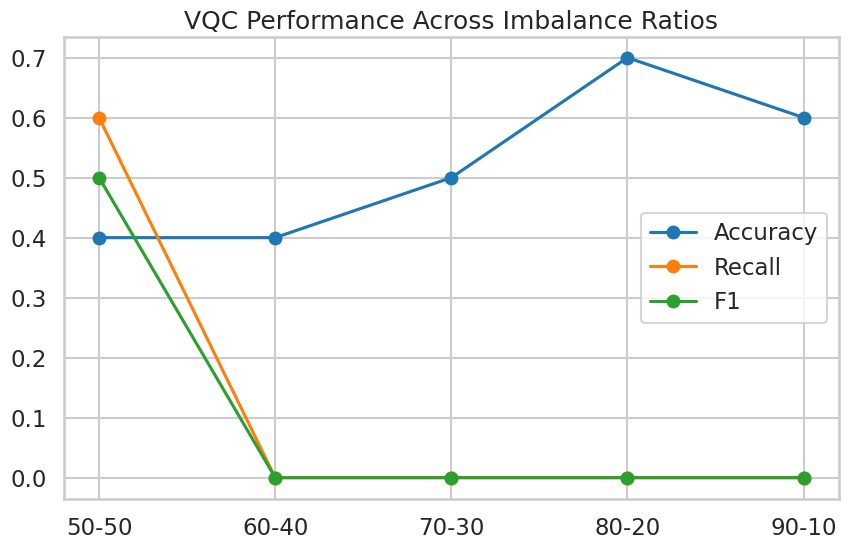

In [78]:
plt.plot(vqc_df["Ratio"], vqc_df["Accuracy"], marker='o', label='Accuracy')
plt.plot(vqc_df["Ratio"], vqc_df["Recall"], marker='o', label='Recall')
plt.plot(vqc_df["Ratio"], vqc_df["F1"], marker='o', label='F1')

plt.title("VQC Performance Across Imbalance Ratios")
plt.legend()
plt.grid(True)
plt.show()

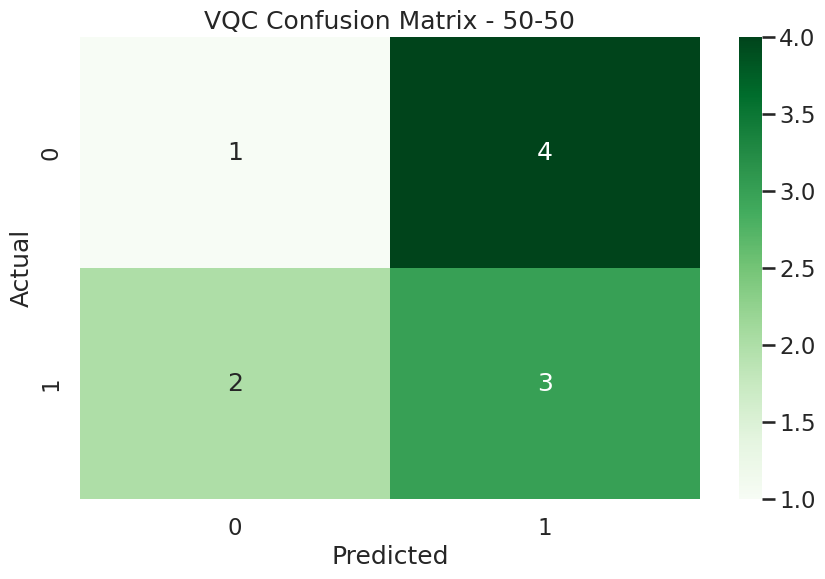

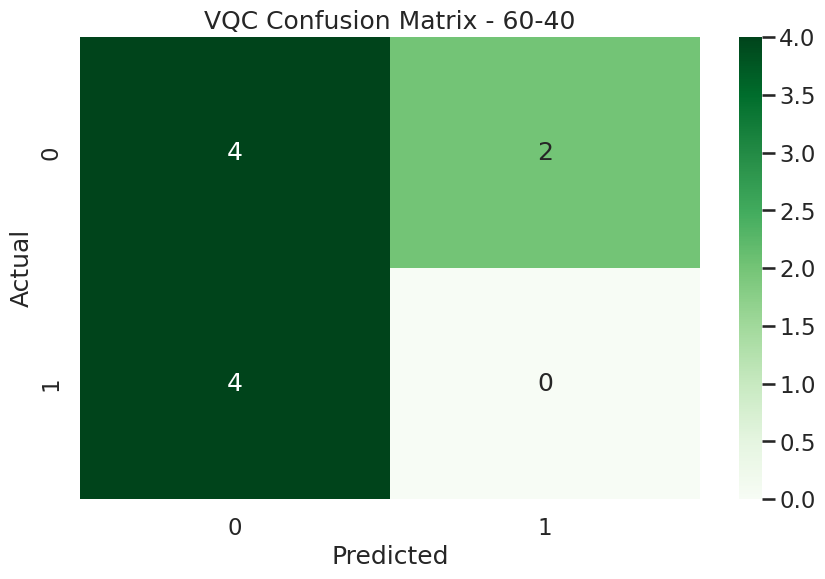

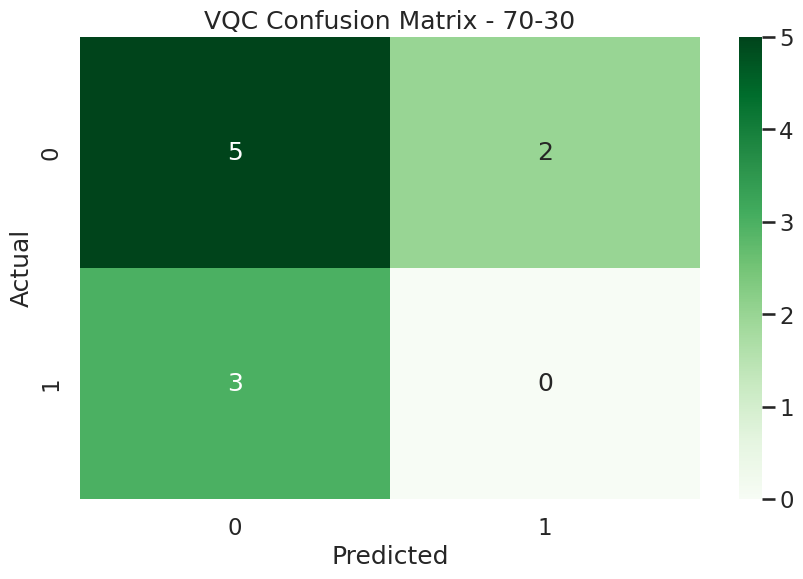

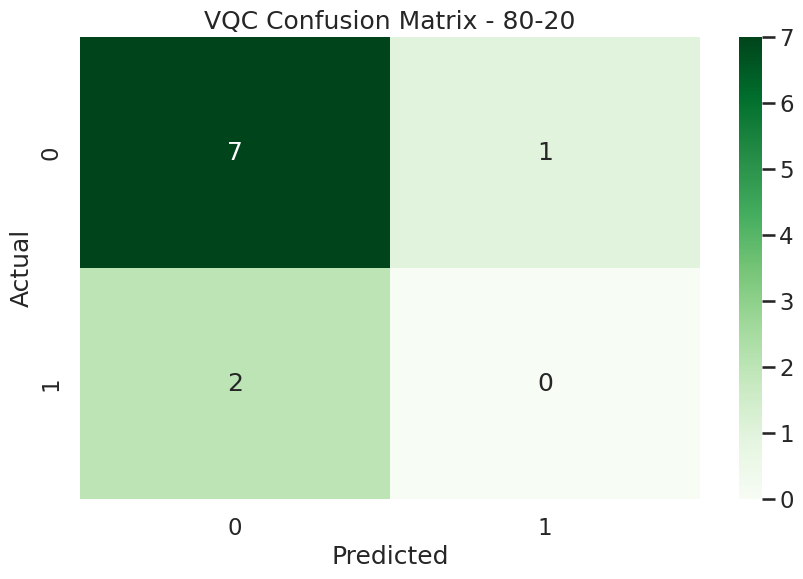

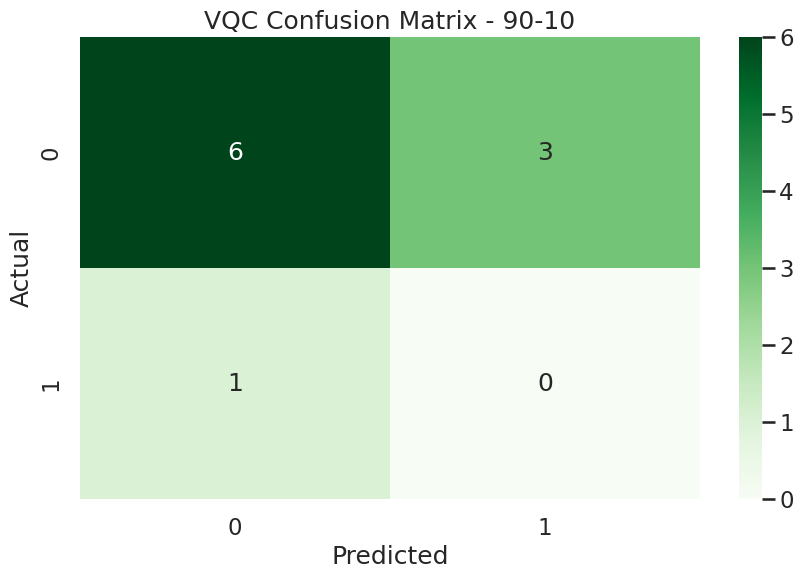

In [79]:
for name, cm in vqc_conf_matrices.items():

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')

    plt.title(f"VQC Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

In [80]:
final_df = svm_df.copy()

final_df["QSVM_F1"] = qsvm_df["F1"]
final_df["VQC_F1"] = vqc_df["F1"]

final_df

,Ratio,Accuracy,Precision,Recall,F1,Error Rate,QSVM_F1,VQC_F1
0,50-50,0.7,0.625,1.0,0.769231,0.3,0.461538,0.5
1,60-40,0.8,1.000,0.5,0.666667,0.2,0.285714,0.0
2,70-30,0.7,0.000,0.0,0.000000,0.3,0.000000,0.0
3,80-20,0.8,0.000,0.0,0.000000,0.2,0.000000,0.0
4,90-10,0.9,0.000,0.0,0.000000,0.1,0.000000,0.0


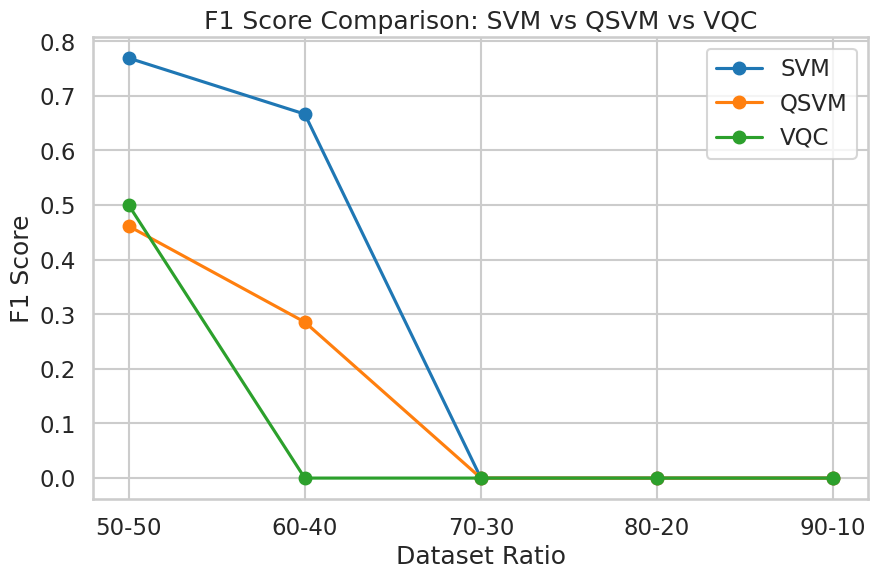

In [81]:
plt.plot(svm_df["Ratio"], svm_df["F1"], marker='o', label='SVM')
plt.plot(qsvm_df["Ratio"], qsvm_df["F1"], marker='o', label='QSVM')
plt.plot(vqc_df["Ratio"], vqc_df["F1"], marker='o', label='VQC')

plt.title("F1 Score Comparison: SVM vs QSVM vs VQC")
plt.xlabel("Dataset Ratio")
plt.ylabel("F1 Score")

plt.legend()
plt.grid(True)
plt.show()

### Final Observations:

- Classical SVM performs well on balanced datasets but fails under extreme imbalance.
- QSVM shows similar behavior due to reliance on kernel-based methods.
- VQC, being a variational model, exhibits different learning dynamics and may show instability due to optimization challenges.

### Key Insight:

All models, including quantum ones, are significantly affected by dataset imbalance.

This highlights that:
- Quantum models do not inherently solve imbalance issues
- Data quality remains a critical factor even in quantum machine learning

### Conclusion:

Dataset imbalance is a fundamental challenge that affects both classical and quantum learning systems, emphasizing the need for imbalance-aware techniques in future QML research.